**Causal Analysis with DoWhy**

This notebook builds on data_exploration.ipynb and the causal DAG defined in causal/dag.py.

### Business question

**What is the causal effect of giving a customer a discount on their probability of purchasing?**

The dataset is observational. Therefore, customers who receive different discount levels can have different characteristics. The variables identified in the data dictionary as confounders are adjusted for in the causal graph.




In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dowhy import CausalModel
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import joblib
import json
import os

sns.set_theme(style="whitegrid")

# Load the cleaned dataset created in data_exploration.ipynb
DATA_PATH = "../data/mockretaildatacleaned.csv"
df = pd.read_csv(DATA_PATH)

df.head()


,customer_id,age,income,previous_purchases,campaign_response,customer_tenure_days,channel,avg_basket_size,discount,purchase
0,1053,41,28100.0,2,0.106,82,in_store,18.61,15,0
1,2991,48,53100.0,5,0.206,483,in_store,44.66,0,0
2,1789,44,26400.0,4,0.137,1,online,28.27,0,1
3,765,44,43000.0,3,0.109,649,online,38.50,0,1
4,3248,24,17100.0,0,0.000,305,in_store,44.09,0,1


## 1. Dataset and causal variables

The cleaned dataset contains **5,000 rows and 10 columns** according to the completed data-exploration notebook.

The causal roles follow the project's data dictionary:

- **Treatment:** discount
- **Outcome:** purchase
- **Identifier:** customer_id
- **Confounders:** age, income, previous_purchases, campaign_response, customer_tenure_days, channel, avg_basket_size

The identifier is not included as a causal variable.


In [32]:
TREATMENT = "discount"
OUTCOME = "purchase"
IDENTIFIER = "customer_id"

CONFOUNDERS = [
    "age",
    "income",
    "previous_purchases",
    "campaign_response",
    "customer_tenure_days",
    "channel",
    "avg_basket_size"
]

print("Dataset shape:", df.shape)
print("Treatment:", TREATMENT)
print("Outcome:", OUTCOME)
print("Identifier:", IDENTIFIER)

print("\nConfounders:")
for variable in CONFOUNDERS:
    print("-", variable)


Dataset shape: (5000, 10)
Treatment: discount
Outcome: purchase
Identifier: customer_id

Confounders:
- age
- income
- previous_purchases
- campaign_response
- customer_tenure_days
- channel
- avg_basket_size


In [33]:
CHANNEL_VAR = "channel"             # W — categorical, encoded separately

NUMERIC_CONFOUNDERS = [c for c in CONFOUNDERS if c != CHANNEL_VAR]

print("W (channel):", CHANNEL_VAR)
print("X (numeric confounders):", NUMERIC_CONFOUNDERS)

W (channel): channel
X (numeric confounders): ['age', 'income', 'previous_purchases', 'campaign_response', 'customer_tenure_days', 'avg_basket_size']


## 2. Treatment distribution

**discount** is the treatment. It has seven observed levels:

**0, 5, 10, 15, 20, 25, 30**

Here, **0** means that no discount was offered.

This is an important point for later causal modeling: the treatment is **not simply a binary variable** in the raw dataset. Week 1 focuses on identifying the causal structure; Week 2 can choose an appropriate treatment representation/model for EconML.


discount
0     2572
5      224
10     437
15     439
20     684
25     439
30     205
Name: count, dtype: int64


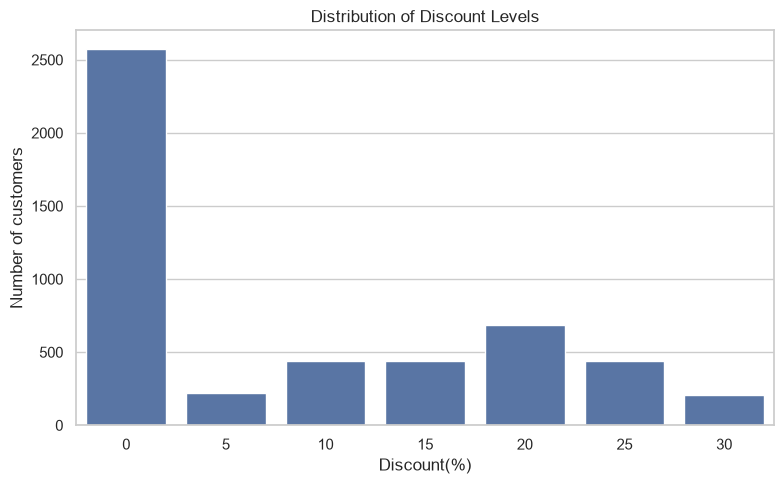

In [34]:
discount_counts = df[TREATMENT].value_counts().sort_index()

print(discount_counts)
plt.figure(figsize=(8, 5))
sns.barplot(x=discount_counts.index.astype(str), y=discount_counts.values)
plt.xlabel("Discount(%)")
plt.ylabel("Number of customers")
plt.title("Distribution of Discount Levels")
plt.tight_layout()
plt.show()


## 3. Outcome distribution

purchase is the outcome:

- 0 = customer did not purchase
- 1 = customer purchased

The data-exploration notebook reports an overall purchase rate of approximately **51.44%** in the original 5,010-row dataset. The causal notebook uses the cleaned 5,000-row dataset for the analysis below.


Purchase counts:
purchase
0    2428
1    2572
Name: count, dtype: int64

Purchase rate in cleaned data: 0.5144


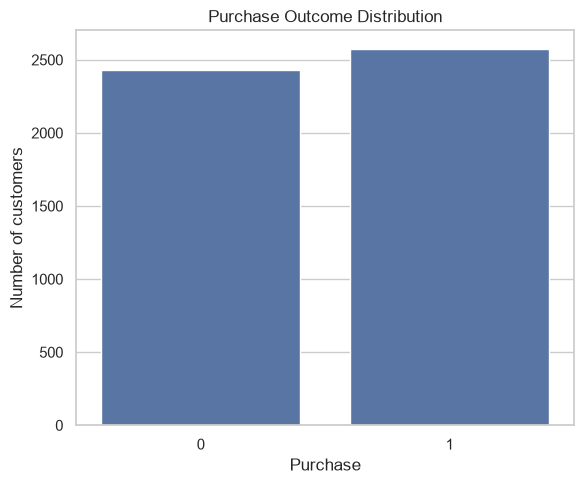

In [35]:
purchase_counts = df[OUTCOME].value_counts().sort_index()
purchase_rate = df[OUTCOME].mean()

print("Purchase counts:")
print(purchase_counts)

print(f"\nPurchase rate in cleaned data: {purchase_rate:.4f}")

plt.figure(figsize=(6, 5))
sns.barplot(
    x=purchase_counts.index.astype(str),
    y=purchase_counts.values
)
plt.xlabel("Purchase")
plt.ylabel("Number of customers")
plt.title("Purchase Outcome Distribution")
plt.tight_layout()
plt.show()


## 4. Confounding sanity check

The data dictionary states that the following variables influence both discount assignment and purchase:

- age
- income
- previous_purchases
- campaign_response
- customer_tenure_days
- channel
- avg_basket_size

A simple sanity check is to compare customer characteristics across discount levels.

If the characteristics differ between discount groups, then comparing raw purchase rates across those groups can mix the discount effect with pre-existing customer differences.


In [36]:
confounding_check = (
    df.groupby(TREATMENT)[
        [
            "age",
            "income",
            "previous_purchases",
            "campaign_response",
            "customer_tenure_days",
            "avg_basket_size"
        ]
    ]
    .mean()
)

confounding_check



,age,income,previous_purchases,campaign_response,customer_tenure_days,avg_basket_size
discount,,,,,,
0,38.751555,42810.653188,1.981337,0.093762,304.779160,36.835638
5,39.558036,48077.232143,2.437500,0.109094,336.883929,38.338304
10,41.050343,48645.080092,2.400458,0.113838,299.929062,39.563524
15,41.872437,49868.792711,2.343964,0.110287,324.776765,39.488451
20,41.163743,47709.210526,2.320175,0.101604,317.820175,38.782237
25,41.567198,49448.747153,2.323462,0.110633,329.956720,39.105308
30,41.019512,47301.951220,2.263415,0.111624,307.443902,39.539707


### Interpretation

The group means are not identical across discount levels. For example, the original exploration showed that customers receiving discounts tended to have different average income, age, previous purchases, and campaign-response values compared with customers receiving no discount.

Therefore, a simple comparison such as:

**purchase rate for discounted customers − purchase rate for non-discounted customers**

would generally be a **naive association**, not automatically a causal effect.



Naive purchase rate by discount level:
discount
0     0.487170
5     0.495536
10    0.556064
15    0.510251
20    0.530702
25    0.599089
30    0.560976
Name: purchase, dtype: float64


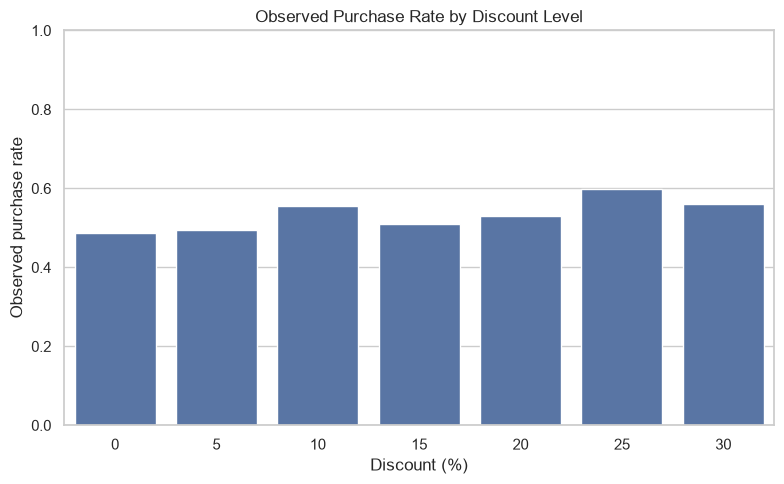

In [38]:
naive_purchase_rate = df.groupby(TREATMENT)[OUTCOME].mean()

print("Naive purchase rate by discount level:")
print(naive_purchase_rate)

plt.figure(figsize=(8, 5))
sns.barplot(
    x=naive_purchase_rate.index.astype(str),
    y=naive_purchase_rate.values
)
plt.xlabel("Discount (%)")
plt.ylabel("Observed purchase rate")
plt.title("Observed Purchase Rate by Discount Level")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


## 5. Why the naive comparison is not causal

Suppose customers receiving larger discounts have, on average, different levels of income, previous purchases, or campaign responsiveness.

Those characteristics can affect **both**:

customer characteristics → discount

and

customer characteristics → purchase

Therefore, the observed relationship between **discount** and **purchase** contains:

**discount effect + effect of customer differences**

The purpose of the causal DAG and DoWhy identification step is to explicitly represent these relationships and determine which variables should be adjusted for under the stated causal assumptions.


## 6. Define the causal DAG

The DAG represents the causal assumptions used for this analysis.

For every confounder:

confounder → discount

and

confounder → purchase

The treatment also directly affects the outcome:

discount → purchase

So the graph represents the causal question:

**What happens to purchase probability if discount is changed, while accounting for the observed confounders?**


In [39]:
graph = """
digraph {
    age -> discount;
    age -> purchase;

    income -> discount;
    income -> purchase;

    previous_purchases -> discount;
    previous_purchases -> purchase;

    campaign_response -> discount;
    campaign_response -> purchase;

    customer_tenure_days -> discount;
    customer_tenure_days -> purchase;

    channel -> discount;
    channel -> purchase;

    avg_basket_size -> discount;
    avg_basket_size -> purchase;

    discount -> purchase;
}
"""

# print(graph)


## 7. Create the DoWhy causal model

DoWhy is used here to translate the DAG and the dataset into a causal model.

At this stage, DoWhy is **not yet estimating the final treatment effect**.

We first ask:

**Is the causal effect identifiable from the graph, and what adjustment strategy should be used?**



In [40]:
model = CausalModel(
    data=df,
    treatment=TREATMENT,
    outcome=OUTCOME,
    graph=graph
)

print("DAG successfully created and loaded into DoWhy.")


DAG successfully created and loaded into DoWhy.


## 8. Identify the causal effect

The next step is **causal identification**.

DoWhy examines the supplied DAG and searches for valid identification strategies.

For this graph, the important result is the **backdoor/general-adjustment estimand**.

The seven listed confounders block the backdoor paths between discount and purchase.

The IV and frontdoor sections can report:

**No such variable(s) found!**

That is not an error. It means the supplied DAG does not contain variables satisfying the requirements for those identification strategies.


In [41]:
print("Identifying causal effect...")

identified_estimand = model.identify_effect(
    proceed_when_unidentifiable=True
)

print(identified_estimand)


Identifying causal effect...
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
     d                                                                         ↪
───────────(E[purchase|previous_purchases,campaign_response,age,customer_tenur ↪
d[discount]                                                                    ↪

↪                                       
↪ e_⟨days,income,⟩_basket_size,channel])
↪                                       
Estimand assumption 1, Unconfoundedness: If U→{discount} and U→purchase then P(purchase|discount,previous_purchases,campaign_response,age,customer_tenure_days,income,avg_basket_size,channel,U) = P(purchase|discount,previous_purchases,campaign_response,age,customer_tenure_days,income,avg_basket_size,channel)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
E

## 9. Understanding the DoWhy output

The key part of the output is the **backdoor estimand**.

Conceptually, it says that the effect of changing **discount** on expected **purchase** can be identified after conditioning on the observed confounders:

- age
- income
- previous_purchases
- campaign_response
- customer_tenure_days
- channel
- avg_basket_size

### What does **d/d[discount]** mean?

The derivative notation represents the causal change in expected purchase with respect to the treatment discount.

### What does the expectation mean?

E[purchase | confounders] represents the expected purchase outcome after accounting for the confounders.

### What does Unconfoundedness mean?

DoWhy is making the causal assumption that, after conditioning on the observed confounders in the graph, there is no remaining unobserved confounding that simultaneously affects treatment and outcome.

This is an assumption of the causal model, not something the software proves from the dataset alone.


## 11. Week 1 conclusion

The causal analysis establishes the following:

- **discount** is the treatment.
- **purchase** is the outcome.
- Seven observed customer characteristics are treated as confounders according to the project data dictionary.
- The cleaned dataset contains 5,000 rows and no missing values or duplicate rows.
- The observed purchase rates vary across discount levels, but these are descriptive/naive comparisons.
- The DAG explicitly represents the confounding relationships.
- DoWhy successfully creates the causal model.
- The backdoor/general-adjustment strategy is identified.
- IV and frontdoor strategies are not available in the supplied DAG.
- The actual treatment-effect estimation is the next stage of the project.



In [ ]:
#second week

In [42]:
#validate required column exist
'''
Target: DML-ready inputs — verify data quality and prepare column documentation.

This section reuses df, TREATMENT, OUTCOME, IDENTIFIER, CONFOUNDERS, CHANNEL_VAR, and NUMERIC_CONFOUNDERS already defined in Part 1 above — nothing is redefined here.'''
required_columns = [IDENTIFIER, TREATMENT, OUTCOME] + CONFOUNDERS
missing_columns = [c for c in required_columns if c not in df.columns]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

print("All required columns are present.")

All required columns are present.


In [43]:
## Check missing values
missing_values = df[required_columns].isnull().sum()
print(missing_values)

rows_with_missing = df[required_columns].isnull().any(axis=1).sum()
print(f"\nRows containing missing values: {rows_with_missing}")


customer_id             0
discount                0
purchase                0
age                     0
income                  0
previous_purchases      0
campaign_response       0
customer_tenure_days    0
channel                 0
avg_basket_size         0
dtype: int64

Rows containing missing values: 0


In [44]:
#check data types
print(df[required_columns].dtypes)

expected_numeric = ["age", "previous_purchases", "customer_tenure_days"]
expected_float = ["income", "campaign_response", "avg_basket_size"]

for col in expected_numeric:
    if not pd.api.types.is_integer_dtype(df[col]):
        print(f"WARNING: expected int dtype for '{col}', got {df[col].dtype}")

for col in expected_float:
    if not pd.api.types.is_float_dtype(df[col]):
        print(f"WARNING: expected float dtype for '{col}', got {df[col].dtype}")

if not pd.api.types.is_object_dtype(df[CHANNEL_VAR]) and not pd.api.types.is_string_dtype(df[CHANNEL_VAR]):
    print(f"WARNING: expected string/object dtype for '{CHANNEL_VAR}', got {df[CHANNEL_VAR].dtype}")

customer_id               int64
discount                  int64
purchase                  int64
age                       int64
income                  float64
previous_purchases        int64
campaign_response       float64
customer_tenure_days      int64
channel                     str
avg_basket_size         float64
dtype: object


In [45]:
## Inspect channel (W) values

print(f"Unique channel values: {df[CHANNEL_VAR].unique().tolist()}")
print("\nValue counts:")
print(df[CHANNEL_VAR].value_counts())

Unique channel values: ['in_store', 'online']

Value counts:
channel
in_store    2735
online      2265
Name: count, dtype: int64


In [48]:
## Column role documentation 
column_roles = {
    "customer_id": {"role": "Identifier", "notes": "Not used as a model input, kept for merging results"},
    "age": {"role": "Confounder (X)", "notes": "Customer age in years"},
    "income": {"role": "Confounder (X)", "notes": "Customer income, float"},
    "previous_purchases": {"role": "Confounder (X)", "notes": "Count of prior purchases"},
    "campaign_response": {"role": "Confounder (X)", "notes": "Historical campaign response rate/score"},
    "customer_tenure_days": {"role": "Confounder (X)", "notes": "Days since customer acquired"},
    "avg_basket_size": {"role": "Confounder (X)", "notes": "Average basket size, float"},
    "channel": {"role": "W", "notes": "Categorical: in_store / online — needs encoding before modeling"},
    "discount": {"role": "Treatment (T)", "notes": "Discount level: 0,5,10,15,20,25,30 — treatment representation (binary vs multi-level) to be finalized by Dishant"},
    "purchase": {"role": "Outcome (Y)", "notes": "Binary purchase indicator"},
}

roles_df = pd.DataFrame(column_roles).T
roles_df.index.name = "column"
roles_df.to_csv("column_roles.csv")

print(roles_df)
print("\nSaved to column_roles.csv")

                                role  \
column                                 
customer_id               Identifier   
age                   Confounder (X)   
income                Confounder (X)   
previous_purchases    Confounder (X)   
campaign_response     Confounder (X)   
customer_tenure_days  Confounder (X)   
avg_basket_size       Confounder (X)   
channel                            W   
discount               Treatment (T)   
purchase                 Outcome (Y)   

                                                                  notes  
column                                                                   
customer_id           Not used as a model input, kept for merging re...  
age                                               Customer age in years  
income                                           Customer income, float  
previous_purchases                             Count of prior purchases  
campaign_response               Historical campaign response rate/score  
c

In [71]:
'''

Target: Finalize feature matrix 

Reuses df, IDENTIFIER, TREATMENT, OUTCOME, CHANNEL_VAR, and NUMERIC_CONFOUNDERS already defined.'''

encoder = OneHotEncoder(sparse_output=False, drop="first")
channel_encoded = encoder.fit_transform(df[[CHANNEL_VAR]])
channel_cols = encoder.get_feature_names_out([CHANNEL_VAR])
channel_df = pd.DataFrame(channel_encoded, columns=channel_cols, index=df.index)

print(f"\nEncoded '{CHANNEL_VAR}' into: {list(channel_cols)}")
print(channel_df.head())

# Save encoder for reuse (e.g., if new data comes in later)
joblib.dump(encoder, "channel_encoder.pkl")




Encoded 'channel' into: ['channel_online']
   channel_online
0             0.0
1             0.0
2             1.0
3             1.0
4             0.0


['channel_encoder.pkl']

In [79]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[NUMERIC_CONFOUNDERS])
X_df = pd.DataFrame(X_scaled, columns=NUMERIC_CONFOUNDERS, index=df.index)

print("Scaled confounders (first 5 rows):")
print(X_df.head())

joblib.dump(scaler, "confounder_scaler.pkl")

Scaled confounders (first 5 rows):
        age    income  previous_purchases  campaign_response  \
0  0.091768 -1.069781           -0.097263           0.065498   
1  0.693695  0.457315            1.747164           1.360137   
2  0.349737 -1.173624            1.132355           0.466836   
3  0.349737 -0.159632            0.517546           0.104338   
4 -1.370054 -1.741703           -1.326881          -1.306819   

   customer_tenure_days  avg_basket_size  
0             -0.978575        -1.892723  
1              0.730126         0.656583  
2             -1.323725        -0.947376  
3              1.437469         0.053753  
4             -0.028350         0.600801  


['confounder_scaler.pkl']

In [80]:
#Assemble final X, T, Y, W
X_final = pd.concat([X_df, channel_df], axis=1)   # X + W combined for modeling
T_final = df[[TREATMENT]].copy()
Y_final = df[[OUTCOME]].copy()
ids = df[[IDENTIFIER]].copy()

print(f"X (confounders + channel): {X_final.shape}")
print(f"T (treatment)             : {T_final.shape}")
print(f"Y (outcome)               : {Y_final.shape}")

X (confounders + channel): (5000, 7)
T (treatment)             : (5000, 1)
Y (outcome)               : (5000, 1)


In [77]:
#Sanity checks before handoff
assert X_final.shape[0] == T_final.shape[0] == Y_final.shape[0] == ids.shape[0], \
    "Row count mismatch between X, T, Y, and identifiers!"

assert X_final.isnull().sum().sum() == 0, "Missing values found in X after encoding/scaling!"
assert T_final.isnull().sum().sum() == 0, "Missing values found in T!"
assert Y_final.isnull().sum().sum() == 0, "Missing values found in Y!"

# Leakage check — outcome/treatment should not appear inside X
leak_check = set(X_final.columns) & {TREATMENT, OUTCOME}
assert not leak_check, f"Leakage detected — X contains: {leak_check}"

print("All sanity checks passed: shapes match, no missing values, no leakage.")

All sanity checks passed: shapes match, no missing values, no leakage.


In [76]:
#Export DML-ready file for handoff 
handoff_df = pd.concat([ids, X_final, T_final, Y_final], axis=1)
handoff_df.to_csv("dml_ready_data.csv", index=False)

print("HANDOFF FILE SAVED: dml_ready_data.csv")
print(f"Columns: {handoff_df.columns.tolist()}")
print(f"Shape  : {handoff_df.shape}")

HANDOFF FILE SAVED: dml_ready_data.csv
Columns: ['customer_id', 'age', 'income', 'previous_purchases', 'campaign_response', 'customer_tenure_days', 'avg_basket_size', 'channel_online', 'discount', 'purchase']
Shape  : (5000, 10)
